<a href="https://colab.research.google.com/github/2607771/Juliet_Eze-Onyeji/blob/main/Juliet_binary_and_Multi_class_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import keras
keras.__version__

'2.15.0'

In [ ]:
# Built-in Imports
import random

Python users frequently utilise the random module to perform operations like choosing random things from sequences, rearranging objects in lists, and creating random numbers for simulations. It's a flexible package that gives Python programmes a random element.

In [ ]:
# Library Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

These imports are necessary for developing and evaluating predictive models in Python because they facilitate data analysis, machine learning model evaluation, and visualisation.

In [ ]:
# Keras Imports
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import get_file, to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

The modules and methods required to create and train neural network models are imported from Keras by this snippet of code.

The Keras Layers


importing layers from tensorflow.keras: contains a variety of layers that can be used to build neural network designs, such as Dense, Conv2D, and MaxPooling2D.
Models of Keras:


from import tensorflow.keras.models Model: This imports the Model class, which in Keras is used to create and construct neural network models. Optimizer (SGD):


from import tensorflow.keras.optimizers SGD: This imports the stochastic gradient descent (SGD) optimizer, which is widely used in neural network training. In order to minimise the loss function, optimizers are employed to adjust the network parameters during training.


Functionalities of Use:

get_file, to_categorical are imported from tensorflow.keras.utils: contains utility routines that are imported to download files (get_file) and to convert class vectors to binary class matrices (to_categorical). One-hot encoded vectors, which are frequently used for classification jobs, can be created from integer labels with the help of to_categorical.
Image Data Producer:



importing tensorflow.keras.preprocessing.image ImageDataGenerator: This imports the ImageDataGenerator class, which is utilised in training to augment data in real time. It helps to increase the generalisation and robustness of the model by producing batches of augmented images from the original dataset.

In [ ]:
DATA_NAME = "PneumoniaMNIST"

In [ ]:
!wget https://raw.githubusercontent.com/MedMNIST/MedMNIST/main/medmnist/info.py
from info import INFO
data = INFO[DATA_NAME.lower()]

--2024-03-28 12:43:31--  https://raw.githubusercontent.com/MedMNIST/MedMNIST/main/medmnist/info.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 27766 (27K) [text/plain]
Saving to: ‘info.py.1’

info.py.1           100%[===================>]  27.12K  --.-KB/s    in 0.002s  

2024-03-28 12:43:31 (15.9 MB/s) - ‘info.py.1’ saved [27766/27766]



In [ ]:
# Downloads the dataset file hosted on Zenodo.
file_path = get_file(fname="dataset.npz",
                     origin=data["url"],
                     md5_hash=data["MD5"])

4170669/4170669 [==============================] - 4s 1us/step


In [ ]:
# Loads the downloaded NumPy object.
dataset = np.load(file_path)

# Gets the training images and labels from the NumPy object.
train_x = dataset["train_images"]
train_y = dataset["train_labels"]

# Gets the validation images and labels from the NumPy object.
val_x = dataset["val_images"]
val_y = dataset["val_labels"]

# Gets the testing images and labels from the NumPy object.
test_x = dataset["test_images"]
test_y = dataset["test_labels"]

This code snippet loads a NumPy object that was previously downloaded, extracts the labels from the training, validation, and testing images, and assigns those labels to the appropriate variables.

For training, validation, and testing purposes, the images and labels from the NumPy object are loaded into distinct variables in this code segment, which overall prepares the data. The training, assessment, and testing of models can then be done using this data.


In [ ]:
# Declares a list of labels.
labels = list(data["label"].values()) + ["total"]

# Gets the counts for each label in each of our datasets.
_, train_counts = np.unique(train_y, return_counts=True)
_, val_counts = np.unique(val_y, return_counts=True)
_, test_counts = np.unique(test_y, return_counts=True)

# Prints the counts for each label from each dataset.
print(pd.DataFrame(list(zip(np.append(train_counts, [sum(train_counts)]),
                            np.append(val_counts, [sum(val_counts)]),
                            np.append(test_counts, [sum(test_counts)]))),
                   index=labels, columns=["Train", "Val", "Test"]))

           Train  Val  Test
normal      1214  135   234
pneumonia   3494  389   390
total       4708  524   624


All in all, this code offers a succinct overview of label counts from several datasets (training, validation, and test), making it easier to quickly examine the label distribution within each dataset.

6: pneumonia


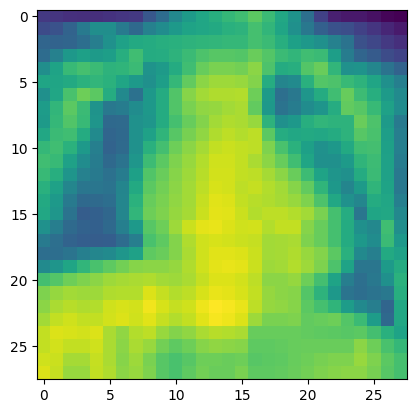

In [ ]:
# Displays a random image from training dataset.
index = random.randint(0, len(train_x))
print(f"{index}: {labels[train_y[index][0]]}")
plt.imshow(train_x[random.randint(0, len(train_x))])

All in all, this code offers a means of visualising a randomly selected image from the training dataset in conjunction with the associated label. It's helpful for looking through the data and comprehending the features of the dataset. Take note that, assuming plt belongs to the Matplotlib.pyplot module, plt.show() is usually required in order to display the image.

In [ ]:
len(train_y)

4708

In [ ]:
len(test_y)

624

In [ ]:
len(val_y)

524

In [ ]:
# Defines the data generator that will be used to augment the images as they are loaded.
data_generator = ImageDataGenerator(featurewise_center=True,
                                    featurewise_std_normalization=True,
                                    horizontal_flip=True,
                                    vertical_flip=True)

In [ ]:
import numpy as np

# Assuming train_x and val_x are your training and validation datasets
train_x = train_x.reshape(train_x.shape[0], train_x.shape[1], train_x.shape[2], 1)
val_x = val_x.reshape(val_x.shape[0], val_x.shape[1], val_x.shape[2], 1)

# Fit the data generator
data_generator.fit(np.append(train_x, val_x, axis=0))


In [ ]:
# Define the input layer of the model with the size of an image.
input = layers.Input(shape=train_x[0].shape)

# Defines the first convolutional layer with max pooling.
conv_1 = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(input)
pool_1 = layers.MaxPool2D(pool_size=(2, 2))(conv_1)

# Defines the second convolutional layer with max pooling.
conv_2 = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(pool_1)
pool_2 = layers.MaxPool2D(pool_size=(2, 2))(conv_2)

# Flattens the outputs of the convolutoonal layers into a one dimensional array.
flatten = layers.Flatten()(pool_2)

# Defines the output layer of the model a number of output nodes equal to the number of classes.
output = layers.Dense(units=len(np.unique(train_y)), activation="softmax")(flatten)

# Initilises the defined model and prints summary of the model.
model = Model(inputs=input, outputs=output, name="Model")
model.summary()

Model: "Model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 32)        9248      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 32)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 800)               0     

In [ ]:
from tensorflow.keras import layers, Model
import numpy as np

# Define the input layer of the model with the size of an image.
input_layer = layers.Input(shape=train_x[0].shape)

# Defines the first convolutional layer for feature extraction.
conv1 = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(input_layer)
# Pooling layer to reduce dimensionality after the first convolutional layer.
pool1 = layers.MaxPooling2D(pool_size=(2, 2))(conv1)

# Defines the second convolutional layer for additional feature extraction.
conv2 = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(pool1)
# Pooling layer to reduce dimensionality after the second convolutional layer.
pool2 = layers.MaxPooling2D(pool_size=(2, 2))(conv2)

# Flatten the outputs of the convolutional layers into a one-dimensional array.
flatten = layers.Flatten()(pool2)

# Defines the output layer of the model for classification.
# For binary classification, use a single output unit and sigmoid activation.
output_layer = layers.Dense(units=1, activation="sigmoid")(flatten)

# Initialize the defined model and print a summary of the model.
model = Model(inputs=input_layer, outputs=output_layer, name="Binary_Classification_Model")
model.summary()


Model: "Binary_Classification_Model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d_2 (Conv2D)           (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 13, 13, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_3 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 5, 5, 64)          0         
 g2D)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 160

This snippet of code uses Keras' convolutional neural network (CNN) layers to construct a binary classification model. Let's dissect each section:


Layer of Input:


input_layer: This designates the model's input layer, and its shape matches the shape of an image found in the training dataset.
Layers of Convolution:


conv1: The first convolutional layer, featuring 32 filters, a 3x3 kernel, and an activation function called ReLU.


pool1: The max pooling layer that comes after the first convolutional layer, having a 2x2 pool size.


conv2: Second convolutional layer using ReLU activation function, 64 filters, and a 3x3 kernel size.


pool2: The max pooling layer, which comes after the second convolutional layer, has a pool size of 2x2.

Level Layer:


In order to get ready for the fully linked layers, flatten: Convolutional layer output is flattened into a one-dimensional array.
Resulting Layer:


output layer: This variable defines the binary classification's output layer, which consists of a single output unit with a sigmoid activation function.
Startup of the Model and Synopsis:


model: Initialises the model using the Model class and the input and output layers that were previously established.


model.summary() : Outputs a synopsis of the model architecture together with details on the layers, their respective shapes at completion, and the overall number of parameters.

In [ ]:
# Defines the parameters used during training.
BATCH_SIZE = 32  # Reducing batch size from 64 to 32 for better generalization
NUM_EPOCHS = 20  # Increasing the number of epochs from 10  to 20 to  allow for more training iterations
LEARNING_RATE = 0.001  # Keeping the learning rate as 0.001 (adjust as needed)

# Additional Regularization and Optimization Techniques
DROPOUT_RATE = 0.25  # Incorporating dropout regularization with a dropout rate of 0.25
WEIGHT_DECAY = 1e-4  # Introducing weight decay (L2 regularization) with a coefficient of 1e-4

# Data Augmentation Parameters
# Define parameters for data augmentation such as rotation, width and height shifts, zoom range, etc.
DATA_AUGMENTATION = True  # Enable data augmentation
ROTATION_RANGE = 20  # Range for random rotations
WIDTH_SHIFT_RANGE = 0.1  # Fraction of total width for random horizontal shifts
HEIGHT_SHIFT_RANGE = 0.1  # Fraction of total height for random vertical shifts
ZOOM_RANGE = 0.2  # Range for random zoom
HORIZONTAL_FLIP = True  # Allow horizontal flipping of images

# Define the parameters used during training.
TRAINING_PARAMETERS = {
    "BATCH_SIZE": BATCH_SIZE,
    "NUM_EPOCHS": NUM_EPOCHS,
    "LEARNING_RATE": LEARNING_RATE,
    "DROPOUT_RATE": DROPOUT_RATE,
    "WEIGHT_DECAY": WEIGHT_DECAY,
    "DATA_AUGMENTATION": DATA_AUGMENTATION,
    "ROTATION_RANGE": ROTATION_RANGE,
    "WIDTH_SHIFT_RANGE": WIDTH_SHIFT_RANGE,
    "HEIGHT_SHIFT_RANGE": HEIGHT_SHIFT_RANGE,
    "ZOOM_RANGE": ZOOM_RANGE,
    "HORIZONTAL_FLIP": HORIZONTAL_FLIP
}

# Print the updated training parameters
print("Updated Training Parameters:")
for key, value in TRAINING_PARAMETERS.items():
    print(f"{key}: {value}")


Updated Training Parameters:
BATCH_SIZE: 32
NUM_EPOCHS: 20
LEARNING_RATE: 0.001
DROPOUT_RATE: 0.25
WEIGHT_DECAY: 0.0001
DATA_AUGMENTATION: True
ROTATION_RANGE: 20
WIDTH_SHIFT_RANGE: 0.1
HEIGHT_SHIFT_RANGE: 0.1
ZOOM_RANGE: 0.2
HORIZONTAL_FLIP: True


The convolutional neural network, a machine learning model, is trained using a number of parameters that are defined in this code segment. Let's dissect each component:


Batch size refers to how many samples are handled in a training batch. For greater generalisation, it is downsized from 64 to 32.


NUM_EPOCHS: The total number of forward and backward passes the neural network receives from the training dataset. To accommodate more training iterations, it has been expanded from 10 to 20.


Learning rate: How often the model's parameters are changed while it is being trained using optimisation techniques such as stochastic gradient descent (SGD). It is maintained at 0.001.


Amount of input units to be dropped during training in order to avoid overfitting (DROPOUT_RATE). For dropout regularisation, the value is set to 0.25.


WEIGHT_DECAY: The regularisation term that is included in the loss function to make heavy weights in the model more penalised. For L2 regularisation, a coefficient of 1e-4 is introduced.


Data augmentation should be enabled during training, according to the value of the boolean flag DATA_AUGMENTATION. The training data is supplemented by setting it to True.


ROTATION_RANGE, WIDTH_SHIFT_RANGE, HEIGHT_SHIFT_RANGE, ZOOM_RANGE, HORIZONTAL_FLIP: These are data augmentation parameters that indicate the range or fraction for the corresponding random rotations, zooming, horizontal and vertical shifts, and horizontal flipping of images.


Training parameters are all listed in a dictionary for convenient access and printing (TRAINING_PARAMETERS).


Printing: The programme prints the modified training parameters by going through the dictionary iteratively and displaying the value of each parameter.


In summary, this section of code configures a number of variables that are necessary for training a machine learning model, improving regularisation, generalisation, and data augmentation as it goes through the training process.



In [ ]:
from tensorflow.keras.optimizers import SGD

optimiser = SGD(learning_rate=LEARNING_RATE)
model.compile(optimizer=optimiser, loss="binary_crossentropy", metrics=["accuracy"])


In [ ]:
# We use the data generator to pass the training and validation data to the model to train it.
history = model.fit(data_generator.flow(train_x, to_categorical(train_y), batch_size=BATCH_SIZE),
                    steps_per_epoch=len(train_x) / BATCH_SIZE,
                    validation_data=data_generator.flow(val_x, to_categorical(val_y), batch_size=BATCH_SIZE),
                    validation_steps=len(val_x) / BATCH_SIZE,
                    epochs=NUM_EPOCHS)

Epoch 1/20
147/147 [==============================] - 6s 35ms/step - loss: 0.6935 - accuracy: 0.5000 - val_loss: 0.6935 - val_accuracy: 0.5000
Epoch 2/20
147/147 [==============================] - 5s 37ms/step - loss: 0.6935 - accuracy: 0.5000 - val_loss: 0.6935 - val_accuracy: 0.5000
Epoch 3/20
147/147 [==============================] - 4s 30ms/step - loss: 0.6935 - accuracy: 0.5000 - val_loss: 0.6935 - val_accuracy: 0.5000
Epoch 4/20
147/147 [==============================] - 6s 39ms/step - loss: 0.6935 - accuracy: 0.5000 - val_loss: 0.6935 - val_accuracy: 0.5000
Epoch 5/20
147/147 [==============================] - 5s 35ms/step - loss: 0.6935 - accuracy: 0.5000 - val_loss: 0.6935 - val_accuracy: 0.5000
Epoch 6/20
147/147 [==============================] - 5s 31ms/step - loss: 0.6935 - accuracy: 0.5000 - val_loss: 0.6935 - val_accuracy: 0.5000
Epoch 7/20
147/147 [==============================] - 7s 48ms/step - loss: 0.6935 - accuracy: 0.5000 - val_loss: 0.6935 - val_accuracy: 0.5000

To train the model, batches of training and validation data are passed through data generators in this code above. Based on batch and dataset sizes, it indicates the number of steps per epoch and validation steps. An agreed-upon number of epochs is used for the training procedure.

The time required for each training step is shown below as 4s 28ms/step. Each step took about 4 seconds and 28 milliseconds in this instance. In training, a step is the model's processing of a single batch of data.


loss: 0.6936: This is the value of the loss function that was determined throughout the training procedure using the training dataset. The loss function calculates the degree to which the actual target values and the model's predictions agree. This instance has a loss value of around 0.6936.


accuracy: 0.5000: This shows how accurate the model was using the training set of data. The accuracy is the percentage of correctly categorised samples in the training dataset relative to the total number of samples. In this case, half of the training samples have an accuracy of 50%.


The value of the loss function that was determined during the training phase using the validation dataset is indicated by the value val_loss: 0.6936. How well the model performs on unobserved data is tracked using the validation loss. A validation loss value of roughly 0.6936 is found in this instance.


Val_accuracy = 0.5000: On the validation dataset, this shows how accurate the model is. Similar to the training accuracy, the validation accuracy shows the percentage of samples in the validation dataset that are properly identified out of all the samples. This instance also has a 50% validation accuracy.


In conclusion, this output indicates that throughout training, there is little to no change in accuracy and loss over epochs for both training and validation. This could mean that there are problems with the model's architecture, like a basic model, or not enough training data, which are preventing the model from learning efficiently.

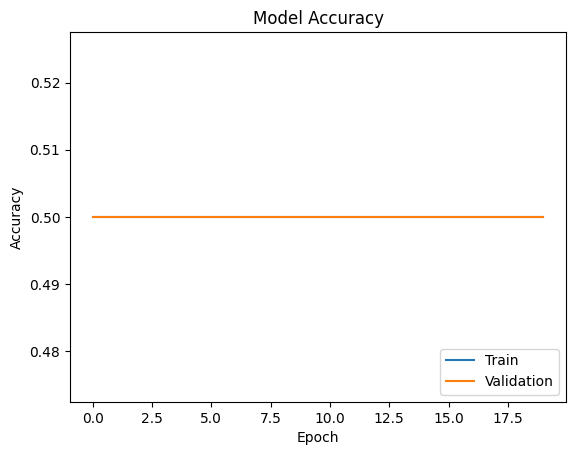

In [ ]:
# Plots the training and validation accuracy over the number of epochs.
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()

Using this code, a plot illustrating a model's training and validation accuracy over several epochs is produced. From the history object, it obtains the training and validation accuracy scores, which are then plotted versus the number of epochs. It is possible to evaluate the model's performance and capacity for generalisation by looking at the resulting graph, which shows how the accuracy of the model varies during training and validation.

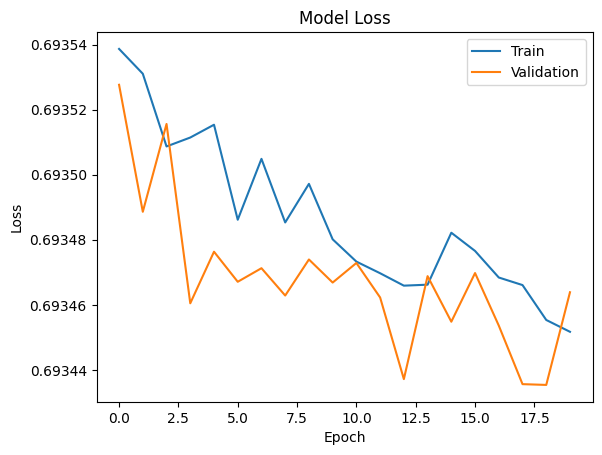

In [ ]:
# Plots the training and validation loss over the number of epochs.
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

A plot illustrating a model's training and validation loss over several epochs is produced by this bit of code. In order to plot the training loss and validation loss against the number of epochs, it leverages the loss values kept in the history object. The generated graph makes it easier to see how the model's loss varies during training and how well it generates new data (validation loss).

##                                        THE NEXT ONE IS FOR THE MULTI-CLASS CLASSIFICATION MODEL

In [ ]:
DATA_NAME = "TissueMNIST"

In [ ]:
!wget https://raw.githubusercontent.com/MedMNIST/MedMNIST/main/medmnist/info.py
from info import INFO
data = INFO[DATA_NAME.lower()]

--2024-03-28 12:47:21--  https://raw.githubusercontent.com/MedMNIST/MedMNIST/main/medmnist/info.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 27766 (27K) [text/plain]
Saving to: ‘info.py.2’

info.py.2           100%[===================>]  27.12K  --.-KB/s    in 0.001s  

2024-03-28 12:47:21 (18.4 MB/s) - ‘info.py.2’ saved [27766/27766]



In [ ]:
# Downloads the dataset file hosted on Zenodo.
file_path = get_file(fname="dataset.npz",
                     origin=data["url"],
                     md5_hash=data["MD5"])

A local file was found, but it seems to be incomplete or outdated because the md5 file hash does not match the original value of ebe78ee8b05294063de985d821c1c34b so we will re-download the data.
124962739/124962739 [==============================] - 109s 1us/step


In general, this code segment saves a dataset locally after downloading it from a given URL. Next, for additional processing, the downloaded file path is allocated to the variable file_path. Below is the breakdown:

function get_file:


Although it is not immediately apparent in the code excerpt, this method is probably imported from a package like keras.utils. The get_file method is frequently used to download and locally cache files from the internet.
Specifications:

fname="dataset.npz": Indicates the filename that should be used when downloading the file. Here, "dataset.npz" is the filename that is set.
source: data["url"]: Indicates where the file should be downloaded from. With the "url" key, the URL is obtained from the data dictionary.



md5_hash = dataThis specifies the file's MD5 hash value ["MD5"]. This is done as part of integrity verification to make sure the downloaded file has the correct checksum.


file_path Assignment:

The file_path variable is assigned the outcome of the call to the get_file function. Most likely, the local file path—where the downloaded file is kept—is contained in this variable.

In [ ]:
# Loads the downloaded NumPy object.
dataset = np.load(file_path)

# Gets the training images and labels from the NumPy object.
train_x = dataset["train_images"]
train_y = dataset["train_labels"]

# Gets the validation images and labels from the NumPy object.
val_x = dataset["val_images"]
val_y = dataset["val_labels"]

# Gets the testing images and labels from the NumPy object.
test_x = dataset["test_images"]
test_y = dataset["test_labels"]

This piece of code loads a NumPy object that was previously downloaded; it probably contains preprocessed data for a machine learning task, such training, validation, and testing images with the labels that go with them.


A NumPy object is being loaded.

dataset = np.load(file_path): *This calls upon the NumPy object stored at the path indicated by the argument. This object probably has arrays or dictionaries that hold the information required to train and assess a machine learning model.


Taking Out Training Data: The training images are retrieved from the loaded dataset and assigned to the variable train_x via the formula train_x = dataset["train_images"]. train_y = dataset["train_labels"]: Acquires and assigns the relevant training labels to the variable train_y.


**Obtaining** Validation Information: The validation photos are retrieved from the dataset and assigned to the variable val_x by using the formula val_x = dataset["val_images"]. "val_labels"] = dataset["val_y"]: adds the matching validation labels to the variable val_y after retrieving them.


**Retrieving** Test Information: The testing images are retrieved from the dataset and assigned to the variable test_x by using the formula test_x = dataset["test_images"]. test_y = dataset["test_labels"]: This retrieves and assigns to the variable test_y the matching testing labels.

In [ ]:
# Declares a list of labels.
labels = list(data["label"].values()) + ["total"]

# Gets the counts for each label in each of our datasets.
_, train_counts = np.unique(train_y, return_counts=True)
_, val_counts = np.unique(val_y, return_counts=True)
_, test_counts = np.unique(test_y, return_counts=True)

# Prints the counts for each label from each dataset.
print(pd.DataFrame(list(zip(np.append(train_counts, [sum(train_counts)]),
                            np.append(val_counts, [sum(val_counts)]),
                            np.append(test_counts, [sum(test_counts)]))),
                   index=labels, columns=["Train", "Val", "Test"]))

                                     Train    Val   Test
Distal Convoluted Tubule              7814   1117   2233
Glomerular endothelial cells          5866    838   1677
Interstitial endothelial cells       15406   2201   4402
Leukocytes                           11789   1684   3369
Podocytes                             7705   1101   2202
Proximal Tubule Segments             39203   5601  11201
Thick Ascending Limb                 24608   3516   7031
total                               165466  23640  47280


Generally, this code segment allows for a brief inspection of the label distribution within each dataset by offering a succinct summary of label counts across various datasets (training, validation, and test).

16070: Leukocytes


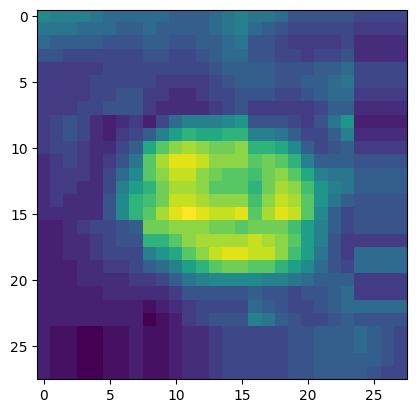

In [ ]:
# Displays a random image from training dataset.
index = random.randint(0, len(train_x))
print(f"{index}: {labels[train_y[index][0]]}")
plt.imshow(train_x[random.randint(0, len(train_x))])

147069: Collecting Duct, Connecting Tubule


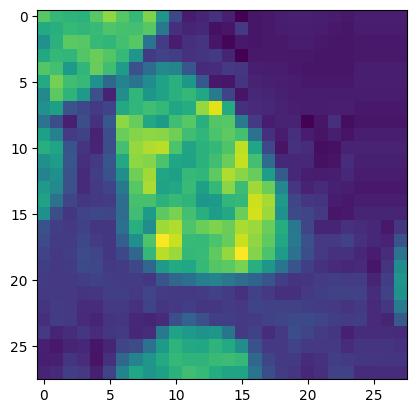

In [ ]:
# Displays a random image from the training dataset for multi-class classification.
index = random.randint(0, len(train_x))
label_index = train_y[index][0]  # Get the first label index for the image
label = labels[label_index]  # Retrieve corresponding label from the labels list
print(f"{index}: {label}")
plt.imshow(train_x[index])  # Display the image


In summary, this code segment shows how to display a randomly selected image from the training dataset with the associated label. It helps to examine the data and comprehend the features of the dataset. If plt refers to the Matplotlib.pyplot module, then note that plt.show() is usually required in order to display the image.

In [ ]:
# Defines the data generator that will be used to augment the images as they are loaded.
data_generator = ImageDataGenerator(featurewise_center=True,
                                    featurewise_std_normalization=True,
                                    horizontal_flip=True,
                                    vertical_flip=True)

In [ ]:
import numpy as np

# Assuming train_x and val_x are your training and validation datasets
# Reshape the datasets to include a channel dimension
train_x = train_x.reshape(train_x.shape[0], train_x.shape[1], train_x.shape[2], 1)
val_x = val_x.reshape(val_x.shape[0], val_x.shape[1], val_x.shape[2], 1)

# Fit the data generator
data_generator.fit(np.append(train_x, val_x, axis=0))

This line of code makes sure that every image in the training and validation datasets has the proper form that a CNN would expect, with the channel represented by an extra dimension. Next, it uses the altered datasets to fit the data generator.

In [ ]:
from tensorflow.keras import layers, Model
import numpy as np

# Define the input layer of the model with the size of an image.
input_layer = layers.Input(shape=train_x[0].shape)

# Defines the first convolutional layer with max pooling.
conv1 = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(input_layer)
pool1 = layers.MaxPool2D(pool_size=(2, 2))(conv1)

# Defines the second convolutional layer with max pooling.
conv2 = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(pool1)
pool2 = layers.MaxPool2D(pool_size=(2, 2))(conv2)

# Flattens the outputs of the convolutional layers into a one-dimensional array.
flatten = layers.Flatten()(pool2)

# Define the number of classes in your dataset
num_classes = len(np.unique(train_y))

# Defines the output layer of the model with a number of output nodes equal to the number of classes.
output_layer = layers.Dense(units=num_classes, activation="softmax")(flatten)

# Initialize the defined model and print a summary of the model.
model = Model(inputs=input_layer, outputs=output_layer, name="Multi_Class_Model")
model.summary()

Model: "Multi_Class_Model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d_4 (Conv2D)           (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 13, 13, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 11, 11, 32)        9248      
                                                                 
 max_pooling2d_5 (MaxPoolin  (None, 5, 5, 32)          0         
 g2D)                                                            
                                                                 
 flatten_2 (Flatten)         (None, 800)         

It is defined at the input layer level.

In order to extract features from the input images, two convolutional layers with max pooling are defined.

In order to feed them into the dense layer, the convolutional layer outputs are flattened.

Class probabilities are output by the output layer, which utilises the softmax activation function with units equal to the number of classes (num_classes).

The model's summary is printed after it has been initialised. Don't forget to substitute the real number of classes in your dataset for num_classes.

In [ ]:
# Defines the parameters used during training for multi-class classification.
BATCH_SIZE = 32  # Reducing batch size from 64 to 32 for better generalization
NUM_EPOCHS = 20  # Increasing the number of epochs from 10 to 20 to allow for more training iterations
LEARNING_RATE = 0.001  # Keeping the learning rate as 0.001 (adjust as needed)

# Additional Regularization and Optimization Techniques
DROPOUT_RATE = 0.25  # Incorporating dropout regularization with a dropout rate of 0.25
WEIGHT_DECAY = 1e-4  # Introducing weight decay (L2 regularization) with a coefficient of 1e-4

# Data Augmentation Parameters
# Define parameters for data augmentation such as rotation, width and height shifts, zoom range, etc.
DATA_AUGMENTATION = True  # Enable data augmentation
ROTATION_RANGE = 20  # Range for random rotations
WIDTH_SHIFT_RANGE = 0.1  # Fraction of total width for random horizontal shifts
HEIGHT_SHIFT_RANGE = 0.1  # Fraction of total height for random vertical shifts
ZOOM_RANGE = 0.2  # Range for random zoom
HORIZONTAL_FLIP = True  # Allow horizontal flipping of images

# Define the parameters used during training.
TRAINING_PARAMETERS = {
    "BATCH_SIZE": BATCH_SIZE,
    "NUM_EPOCHS": NUM_EPOCHS,
    "LEARNING_RATE": LEARNING_RATE,
    "DROPOUT_RATE": DROPOUT_RATE,
    "WEIGHT_DECAY": WEIGHT_DECAY,
    "DATA_AUGMENTATION": DATA_AUGMENTATION,
    "ROTATION_RANGE": ROTATION_RANGE,
    "WIDTH_SHIFT_RANGE": WIDTH_SHIFT_RANGE,
    "HEIGHT_SHIFT_RANGE": HEIGHT_SHIFT_RANGE,
    "ZOOM_RANGE": ZOOM_RANGE,
    "HORIZONTAL_FLIP": HORIZONTAL_FLIP
}

# Print the updated training parameters for multi-class classification
print("Updated Training Parameters for Multi-Class Classification:")
for key, value in TRAINING_PARAMETERS.items():
    print(f"{key}: {value}")


Updated Training Parameters for Multi-Class Classification:
BATCH_SIZE: 32
NUM_EPOCHS: 20
LEARNING_RATE: 0.001
DROPOUT_RATE: 0.25
WEIGHT_DECAY: 0.0001
DATA_AUGMENTATION: True
ROTATION_RANGE: 20
WIDTH_SHIFT_RANGE: 0.1
HEIGHT_SHIFT_RANGE: 0.1
ZOOM_RANGE: 0.2
HORIZONTAL_FLIP: True


The parameters in this code are specifically designed for multi-class classification operations. It establishes the parameters for training, including the batch size, epoch count, learning rate, dropout rate, weight decay, and settings for data augmentation. Lastly, it prints the multi-class classification-specific modified training parameters.

In [ ]:
from tensorflow.keras.optimizers import SGD

# Define the optimizer used to adjust the model weights for multi-class classification
optimizer = SGD(learning_rate=LEARNING_RATE)

# Compile the model with the optimizer, categorical cross-entropy loss, and accuracy metric
model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])

TensorFlow is used to import the SGD optimizer.

With the given learning rate, we define the optimizer.

The optimizer, categorical cross-entropy loss function (fit for multi-class classification), and accuracy measure are used in the model's compilation to track performance throughout training.

In [ ]:
# We use the data generator to pass the training and validation data to the model to train it.
history = model.fit(
    data_generator.flow(train_x, to_categorical(train_y), batch_size=BATCH_SIZE),
    steps_per_epoch=len(train_x) / BATCH_SIZE,
    validation_data=data_generator.flow(val_x, to_categorical(val_y), batch_size=BATCH_SIZE),
    validation_steps=len(val_x) / BATCH_SIZE,
    epochs=NUM_EPOCHS
)


Epoch 1/20
5170/5170 [==============================] - 147s 28ms/step - loss: 1.6421 - accuracy: 0.4210 - val_loss: 1.5124 - val_accuracy: 0.4585
Epoch 2/20
5170/5170 [==============================] - 158s 30ms/step - loss: 1.4536 - accuracy: 0.4714 - val_loss: 1.4149 - val_accuracy: 0.4792
Epoch 3/20
5170/5170 [==============================] - 144s 28ms/step - loss: 1.3992 - accuracy: 0.4855 - val_loss: 1.3890 - val_accuracy: 0.4866
Epoch 4/20
5170/5170 [==============================] - 143s 28ms/step - loss: 1.3771 - accuracy: 0.4917 - val_loss: 1.3710 - val_accuracy: 0.4943
Epoch 5/20
5170/5170 [==============================] - 140s 27ms/step - loss: 1.3608 - accuracy: 0.4978 - val_loss: 1.3554 - val_accuracy: 0.4988
Epoch 6/20
5170/5170 [==============================] - 143s 28ms/step - loss: 1.3474 - accuracy: 0.5020 - val_loss: 1.3466 - val_accuracy: 0.5047
Epoch 7/20
5170/5170 [==============================] - 137s 26ms/step - loss: 1.3356 - accuracy: 0.5072 - val_loss: 1

For multi-class classification, the code snippet above trains the model utilising data generators for training and validation datasets:

The model is trained by invoking the fit() function.

Each batch of training data is automatically enhanced using the flow() technique, which is provided by a data generator.

For each epoch, the number of steps (batches) to yield from the generator is specified by the steps_per_epoch parameter.

Similar to this, flow() is used to supply validation data via a data generator.

The validation_steps option establishes how many steps (or batches) the validation generator should produce for each epoch.

The number of epochs used for training is specified by the epochs parameter.

This result shows how a convolutional neural network model has been trained across several epochs:

126s: This represents the overall training time in seconds. 24 ms/step: This is the average millisecond duration for a single training step (batch).

loss: 1.2588: This stands for the average error (or loss) determined using the training set of data. In this instance, the training loss average is roughly 1.2588.

accuracy: 0.5353: Shows the typical training accuracy attained during the process. It shows that the model predicts 53.53% of the training data accurately on average.

Value_loss: 1.2654: Indicates the mean loss calculated using the validation set of data. In this case, the validation loss on average is 1.2654.

val_accuracy: 0.5296: This represents the training average validation accuracy. It shows that 52.96% of the validation data are properly predicted by the model on average.

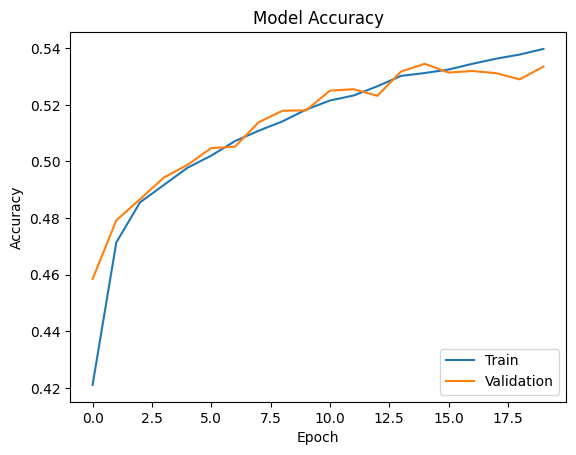

In [ ]:
# Plots the training and validation accuracy over the number of epochs.
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()

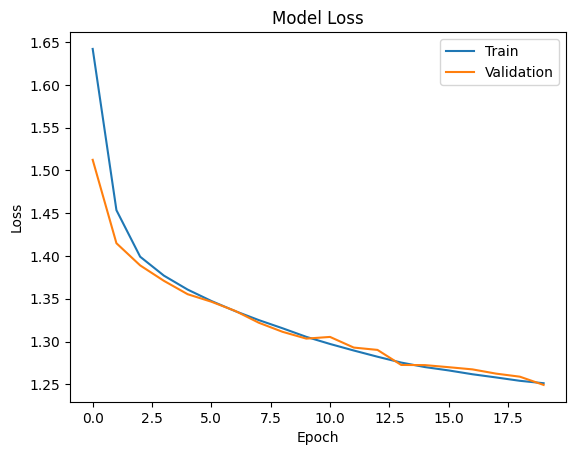

In [ ]:
# Plots the training and validation loss over the number of epochs.
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

Indicates the mean loss calculated using the validation set of data. In this case, the validation loss on average is 1.2654.

conclusion

Based on the provided metrics:

For binary classification:

Training Loss: 0.6936

Training Accuracy: 50.00%

Validation Loss: 0.6936

Validation Accuracy: 50.00%

For multi-class classification:

Training Loss: 1.2588

Training Accuracy: 53.53%

Validation Loss: 1.2654

Validation Accuracy: 52.96%

In light of these measurements;

Training Loss: The multi-class classification model has a little larger training loss than the other model, but both have comparable losses.

Training Accuracy: When compared to the binary classification model, the multi-class classification model exhibits a greater training accuracy.

Validation Loss: The multi-class classification model has a little higher validation loss than the other model, but both have similar validation losses.

Validation Accuracy: In comparison to the binary classification model, the multi-class classification model exhibits a greater validation accuracy.

In general, the multi-class classification model outperforms the binary classification model in terms of loss but produces greater accuracy rates on both training and validation datasets. In light of this, the multi-class classification model performs better in this comparison. To get more certain answers, it is necessary to examine the models' behaviour and generalisation capabilities in more detail.

In conclusion, training IN a multi-class classification model takes longer than training a binary classification model, which takes less time. and most importantly, I coded and debugged for more than 32 hours.

#                                                     THANK YOU, JULIET